In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('US.csv')
data.head()

/var/folders/p0/r417rfgs0v73_8rbp8lwg9b40000gn/T/ipykernel_14091/3513932028.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('US.csv')


,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,...,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$15,000 - $24,999",INC,INC1525
1,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$25,000 - $34,999",INC,INC2535
2,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$35,000 - $49,999",INC,INC3550
3,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$50,000 - $74,999",INC,INC5075
4,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$75,000 or greater",INC,INC75PLUS


In [3]:
data.shape

(110880, 33)

In [4]:
data.dtypes

YearStart                       int64
YearEnd                         int64
LocationAbbr                   object
LocationDesc                   object
Datasource                     object
Class                          object
Topic                          object
Question                       object
Data_Value_Unit                object
Data_Value_Type                object
Data_Value                    float64
Data_Value_Alt                float64
Data_Value_Footnote_Symbol     object
Data_Value_Footnote            object
Low_Confidence_Limit          float64
High_Confidence_Limit         float64
Sample_Size                   float64
Total                          object
Age(years)                     object
Education                      object
Sex                            object
Income                         object
Race/Ethnicity                 object
GeoLocation                    object
ClassID                        object
TopicID                        object
QuestionID  

In [5]:

pd.set_option('display.max_rows', None)     # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_colwidth', None) # Show full content of each cell
print(data.apply(lambda col: col.unique()))


YearStart                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [6]:
data.isna().sum()

YearStart                          0
YearEnd                            0
LocationAbbr                       0
LocationDesc                       0
Datasource                         0
Class                              0
Topic                              0
Question                           0
Data_Value_Unit               106260
Data_Value_Type                    0
Data_Value                     13214
Data_Value_Alt                 13214
Data_Value_Footnote_Symbol     97666
Data_Value_Footnote            97666
Low_Confidence_Limit           13214
High_Confidence_Limit          13214
Sample_Size                    13214
Total                         106920
Age(years)                     87120
Education                      95040
Sex                           102960
Income                         83160
Race/Ethnicity                 79200
GeoLocation                     2016
ClassID                            0
TopicID                            0
QuestionID                         0
D

In [7]:
data['StratificationCategory1'].value_counts()


StratificationCategory1
Race/Ethnicity    31680
Income            27720
Age (years)       23760
Education         15840
Sex                7920
Total              3960
Name: count, dtype: int64

In [8]:
data['Stratification1'].value_counts()

Stratification1
$15,000 - $24,999                   3960
$25,000 - $34,999                   3960
Some college or technical school    3960
Other                               3960
Non-Hispanic White                  3960
Non-Hispanic Black                  3960
Male                                3960
Less than high school               3960
Less than $15,000                   3960
Hispanic                            3960
High school graduate                3960
Hawaiian/Pacific Islander           3960
Female                              3960
Data not reported                   3960
College graduate                    3960
Asian                               3960
American Indian/Alaska Native       3960
65 or older                         3960
55 - 64                             3960
45 - 54                             3960
35 - 44                             3960
25 - 34                             3960
2 or more races                     3960
18 - 24                             3960


In [9]:
data['QuestionID'].value_counts()

QuestionID
Q036    21560
Q037    21560
Q047    21560
Q043     9240
Q044     9240
Q045     9240
Q046     9240
Q018     4620
Q019     4620
Name: count, dtype: int64

In [10]:
data[['QuestionID','Question']].value_counts()

QuestionID  Question                                                                                                                                                                                                                                                                            
Q036        Percent of adults aged 18 years and older who have obesity                                                                                                                                                                                                                              21560
Q037        Percent of adults aged 18 years and older who have an overweight classification                                                                                                                                                                                                         21560
Q047        Percent of adults who engage in no leisure-time physical activity                                      

In [11]:
data1 = data[data['StratificationCategory1'] == 'Sex'].copy()
data2 = data[data['StratificationCategory1'] == 'Age (years)'].copy()
data3 = data[data['StratificationCategory1'] == 'Income'].copy()
data4 = data[data['StratificationCategory1'] == 'Education'].copy()
data5 = data[data['StratificationCategory1'] == 'Race/Ethnicity'].copy()

In [12]:
data1.shape

(7920, 33)

In [13]:
data1.isna().sum()

YearStart                        0
YearEnd                          0
LocationAbbr                     0
LocationDesc                     0
Datasource                       0
Class                            0
Topic                            0
Question                         0
Data_Value_Unit               7590
Data_Value_Type                  0
Data_Value                     228
Data_Value_Alt                 228
Data_Value_Footnote_Symbol    7692
Data_Value_Footnote           7692
Low_Confidence_Limit           228
High_Confidence_Limit          228
Sample_Size                    228
Total                         7920
Age(years)                    7920
Education                     7920
Sex                              0
Income                        7920
Race/Ethnicity                7920
GeoLocation                    144
ClassID                          0
TopicID                          0
QuestionID                       0
DataValueTypeID                  0
LocationID          

In [14]:
import pandas as pd

def clean_with_threshold(df, threshold=0.5):
    # Calculate minimum number of non-null values required to keep a column
    min_non_null = int((1 - threshold) * len(df))
    # 1. Drop columns exceeding null threshold
    df_clean = df.dropna(axis=1, thresh=min_non_null)
    # 2. Drop rows with any remaining null values
    df_clean = df_clean.dropna(axis=0)
    # 3. Reset index
    df_clean = df_clean.reset_index(drop=True)
    return df_clean

In [15]:
data1=clean_with_threshold(data1)
data2=clean_with_threshold(data2)
data3=clean_with_threshold(data3)
data4=clean_with_threshold(data4)
data5=clean_with_threshold(data5)

In [16]:
print(data1.shape)
print(data2.shape)
print(data3.shape)
print(data4.shape)
print(data5.shape)

(7548, 25)
(22644, 25)
(26413, 25)
(15096, 25)
(20178, 25)


In [17]:
def pivot_health_dataset(df):
    important_cols = [
        "YearStart",
        "YearEnd",
        "LocationDesc",
        "StratificationCategory1",
        "Stratification1",
        "Data_Value_Type",
        "Sample_Size"
    ]
    # Remove rows that cannot be pivoted
    df = df.dropna(
        subset=["QuestionID", "Data_Value"]
    )
    pivot_df = df.pivot_table(
        index=important_cols,
        columns="QuestionID",
        values="Data_Value",
        aggfunc="first"
    )
    pivot_df.columns.name = None
    pivot_df = pivot_df.reset_index()

    return pivot_df

In [18]:
df1 = pivot_health_dataset(data1)
print(df1.shape)
df1.nunique()

(6043, 16)


YearStart                    14
YearEnd                      14
LocationDesc                 54
StratificationCategory1       1
Stratification1               2
Data_Value_Type               1
Sample_Size                3888
Q018                        174
Q019                        144
Q036                        217
Q037                        195
Q043                        235
Q044                        219
Q045                        240
Q046                        253
Q047                        246
dtype: int64

In [19]:
df2 = pivot_health_dataset(data2)
df3 = pivot_health_dataset(data3)
df4 = pivot_health_dataset(data4)
df5 = pivot_health_dataset(data5)
print(df2.shape)
print(df3.shape)
print(df4.shape)
print(df5.shape)

(17970, 16)
(20780, 16)
(11986, 16)
(14791, 16)


In [20]:
def merge_two_datasets(df_a, df_b, name_a="A", name_b="B"):
    print(f"\n--- BEFORE MERGE ---")
    print(f"{name_a} shape:", df_a.shape)
    print(f"{name_b} shape:", df_b.shape)

    # Align columns (important for safety)
    all_columns = sorted(set(df_a.columns).union(set(df_b.columns)))
    df_a_aligned = df_a.reindex(columns=all_columns)
    df_b_aligned = df_b.reindex(columns=all_columns)
    # Vertical merge
    merged = pd.concat([df_a_aligned, df_b_aligned], axis=0, ignore_index=True)
    print(f"\n--- AFTER MERGE ({name_a} + {name_b}) ---")
    print("Merged shape:", merged.shape)
    return merged

In [21]:
merge1 = merge_two_datasets(df1,df2)


--- BEFORE MERGE ---
A shape: (6043, 16)
B shape: (17970, 16)

--- AFTER MERGE (A + B) ---
Merged shape: (24013, 16)


In [22]:
merge2 = merge_two_datasets(df3,merge1)
merge3 = merge_two_datasets(df4,merge2)
merged = merge_two_datasets(df5,merge3)


--- BEFORE MERGE ---
A shape: (20780, 16)
B shape: (24013, 16)

--- AFTER MERGE (A + B) ---
Merged shape: (44793, 16)

--- BEFORE MERGE ---
A shape: (11986, 16)
B shape: (44793, 16)

--- AFTER MERGE (A + B) ---
Merged shape: (56779, 16)

--- BEFORE MERGE ---
A shape: (14791, 16)
B shape: (56779, 16)

--- AFTER MERGE (A + B) ---
Merged shape: (71570, 16)


In [23]:
merged.dtypes

Data_Value_Type             object
LocationDesc                object
Q018                       float64
Q019                       float64
Q036                       float64
Q037                       float64
Q043                       float64
Q044                       float64
Q045                       float64
Q046                       float64
Q047                       float64
Sample_Size                float64
Stratification1             object
StratificationCategory1     object
YearEnd                      int64
YearStart                    int64
dtype: object

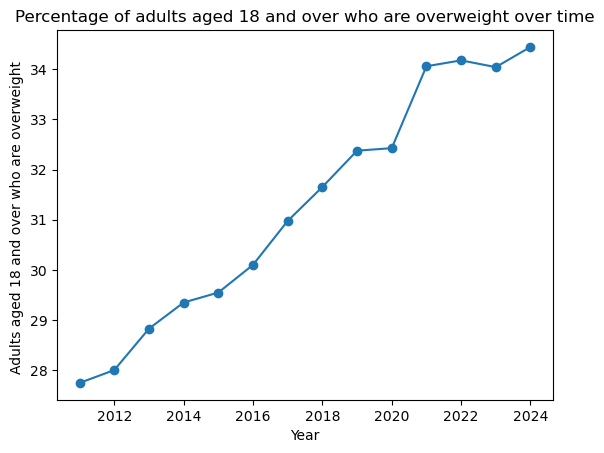

In [ ]:
df_plot = merged.copy()
# Aggregate in case multiple rows per year/location exist
trend = df_plot.groupby("YearStart")["Q036"].mean()
plt.figure()
plt.plot(trend.index, trend.values, marker="o")
plt.title("Percentage of adults aged 18 and over who are overweight over time")
plt.xlabel("Year")
plt.ylabel("Adults aged 18 and over who are overweight")
plt.show()

In [25]:
merged['StratificationCategory1'].value_counts()

StratificationCategory1
Income            20780
Age (years)       17970
Race/Ethnicity    14791
Education         11986
Sex                6043
Name: count, dtype: int64

In [26]:
merged['Stratification1'].value_counts()

Stratification1
55 - 64                             3042
45 - 54                             3033
Male                                3027
65 or older                         3021
Female                              3016
College graduate                    3013
High school graduate                3013
35 - 44                             3009
Data not reported                   3009
Some college or technical school    3000
$15,000 - $24,999                   2995
$75,000 or greater                  2983
Non-Hispanic White                  2975
25 - 34                             2965
Less than high school               2960
$50,000 - $74,999                   2954
Less than $15,000                   2952
$35,000 - $49,999                   2950
$25,000 - $34,999                   2937
18 - 24                             2900
Hispanic                            2710
2 or more races                     2362
Non-Hispanic Black                  2323
Asian                               1741


QuestionID  Question                                                                                                                                                                                                                                                                            
Q036        Percent of adults aged 18 years and older who have obesity                                                                                                                                                                                                                             
Q037        Percent of adults aged 18 years and older who have an overweight classification                                                                                                                                                                                                       
Q047        Percent of adults who engage in no leisure-time physical activity                                                                                                                                                                                                                    
Q043        Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)                                                                                  
Q044        Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic physical activity (or an equivalent combination) and engage in muscle-strengthening activities on 2 or more days a week     
Q045        Percent of adults who achieve more than 300 minutes a week of moderate-intensity aerobic physical activity or 150 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)                                                                                 
Q046        Percent of adults who engage in muscle-strengthening activities on 2 or more days a week                                                                                                                                                                                                
Q018        Percent of adults who report consuming fruit less than one time daily                                                                                                                                                                                                                   
Q019        Percent of adults who report consuming vegetables less than one time daily                                                                                                                                                                                                             


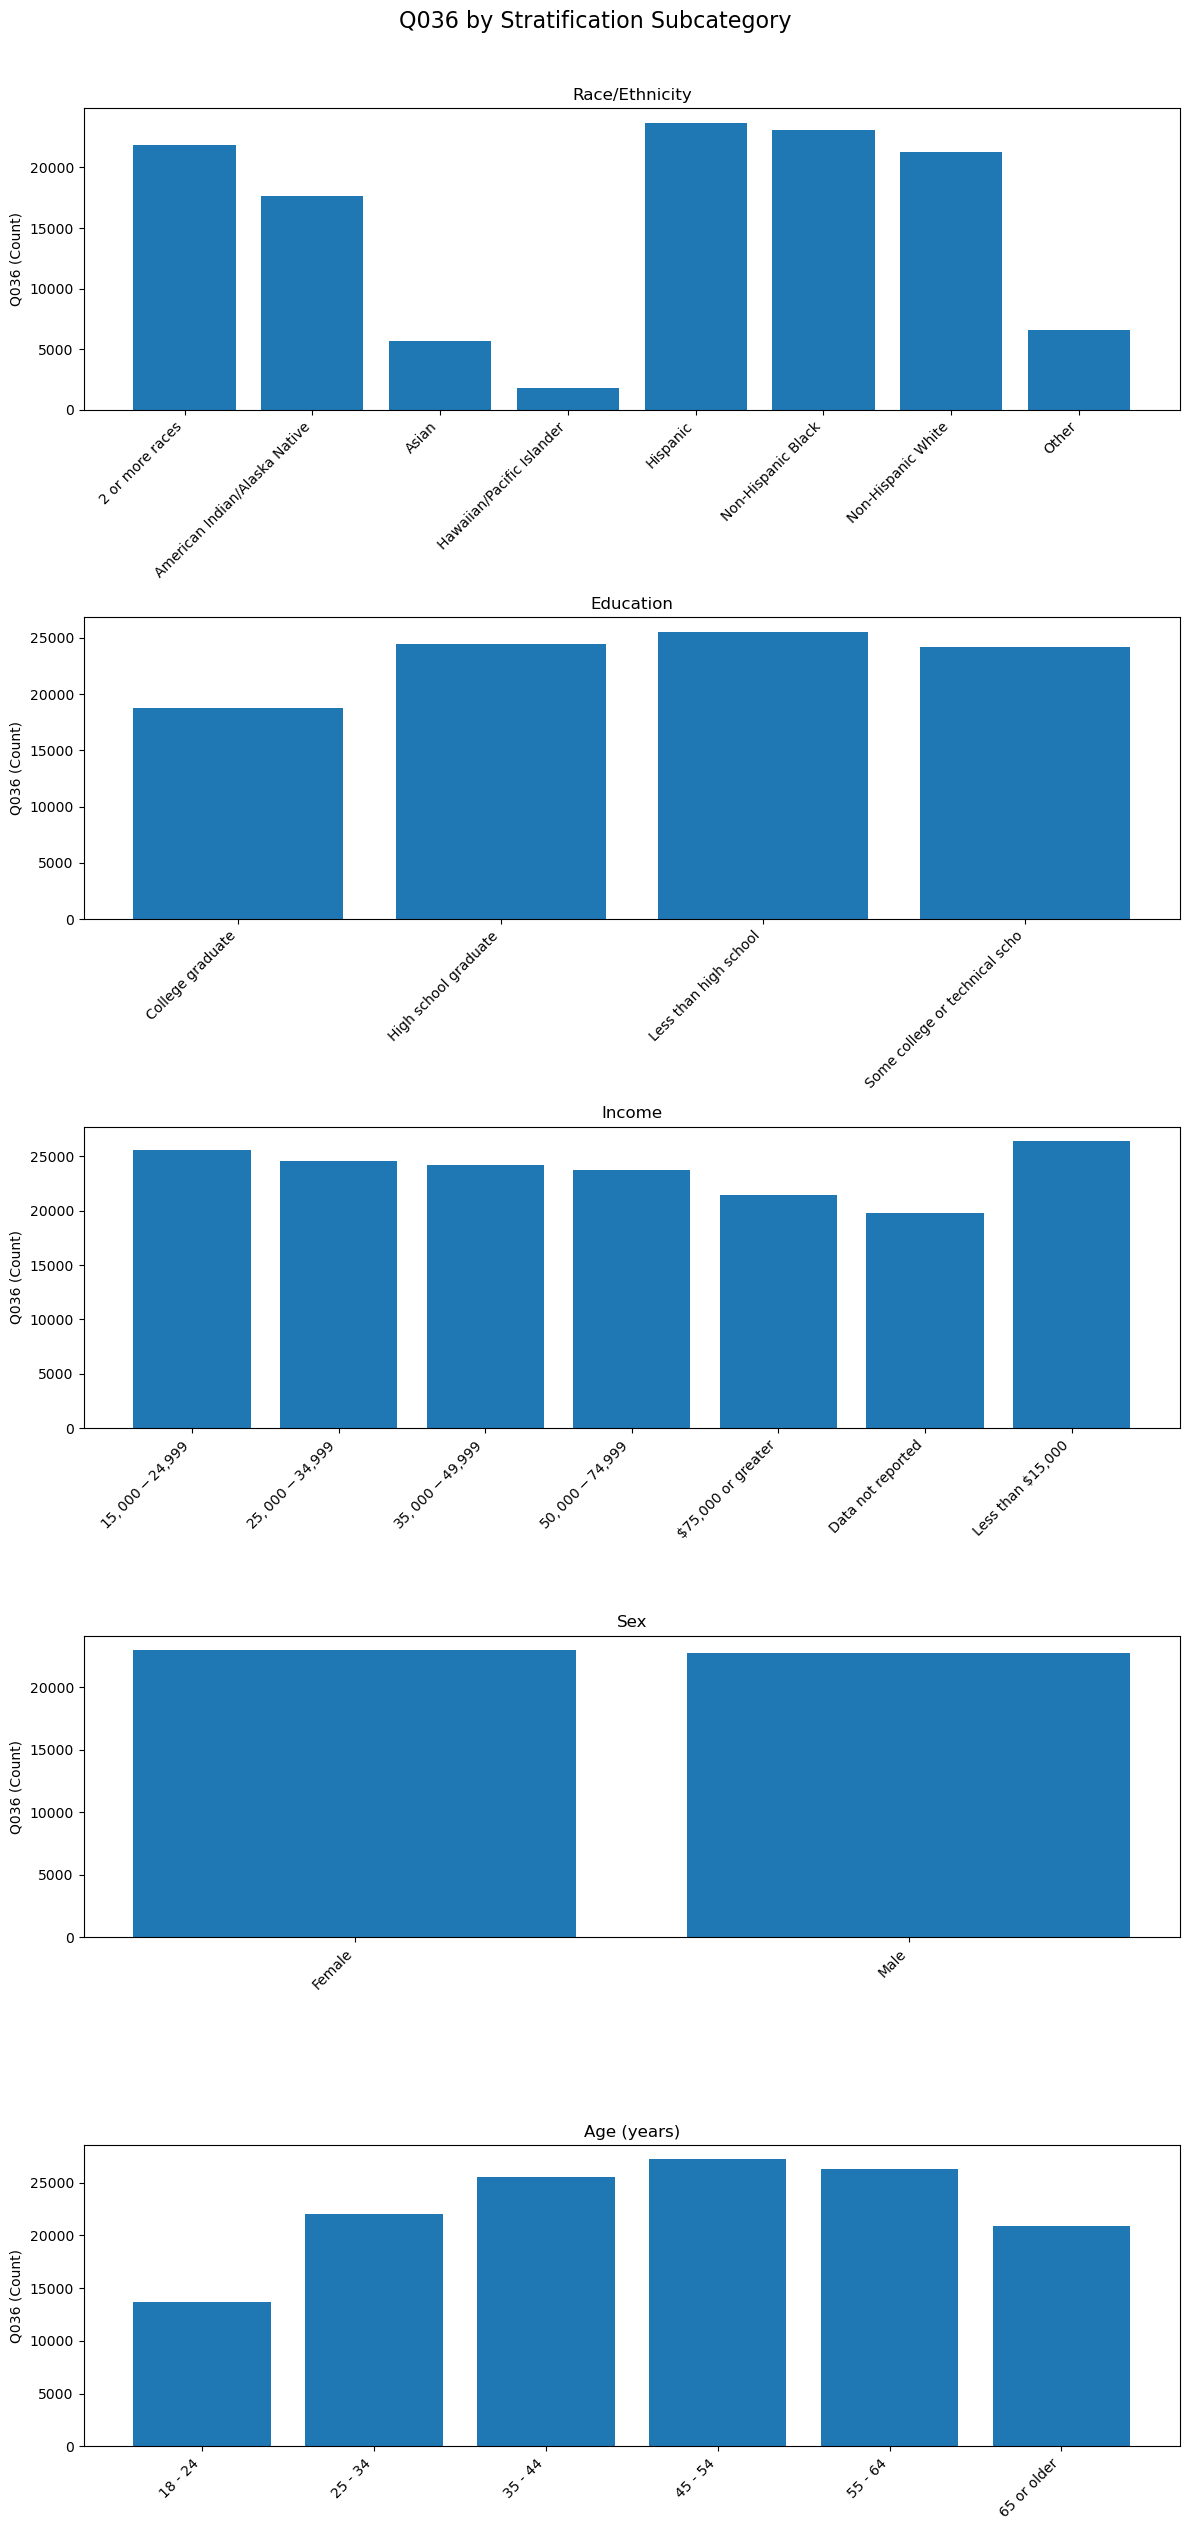

In [41]:
categories = df_plot['StratificationCategory1'].unique()
n = len(categories)

fig, axes = plt.subplots(n, 1, figsize=(12, 5 * n))

for ax, cat in zip(axes, categories):
    subset = df_plot[df_plot['StratificationCategory1'] == cat]
    subcounts = subset.groupby('Stratification1')['Q036'].sum()
    
    ax.bar(subcounts.index, subcounts.values)
    ax.set_title(f"{cat}")
    ax.set_ylabel("Q036 (Count)")
    ax.tick_params(axis='x', rotation=45)
    
    # Wrap long x-axis labels so they don't overlap
    ax.set_xticks(range(len(subcounts.index)))
    ax.set_xticklabels(
        [label[:30] for label in subcounts.index],  # truncate at 30 chars if needed
        rotation=45, ha='right'
    )

plt.suptitle("Q036 by Stratification Subcategory", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()